# Team/Constructor Effect Diagnostics (v6)

This notebook checks whether the v6 model behaves more like:

- **direction-sensitive** (attacker stronger than defender matters via signed deltas), or
- **magnitude-sensitive** (absolute rank gap matters more than direction).

It uses the existing v6 artifact (`models/artifacts/overtake_model_v6.pkl`) and v6 scenario data.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data" / "v6"
ARTIFACTS_DIR = ROOT / "models" / "artifacts"
MODEL_PATH = ARTIFACTS_DIR / "overtake_model_v6.pkl"
META_PATH = ARTIFACTS_DIR / "overtake_model_v6_meta.json"

TRAIN_YEARS = [2022, 2023, 2024]
TEST_YEARS = [2025]
TARGET = "label"

In [2]:
def load_years(years):
    frames = []
    for year in years:
        path = DATA_DIR / f"scenarios_{year}.csv"
        if not path.exists():
            print(f"WARNING: missing {path}")
            continue
        frame = pd.read_csv(path)
        frame["source_year"] = year
        frames.append(frame)
        print(f"{year}: {len(frame):,} rows | positive rate={frame[TARGET].mean():.2%}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("Train split")
df_train = load_years(TRAIN_YEARS)
print("\nTest split")
df_test = load_years(TEST_YEARS)

# Mirror model_testing_6 framing: remove pit-stop involved rows
for name, frame in [("train", df_train), ("test", df_test)]:
    before = len(frame)
    frame.drop(frame[frame["pit_stop_involved"].astype(bool)].index, inplace=True)
    after = len(frame)
    print(f"{name}: removed pit-stop rows -> {before:,} -> {after:,}")

Train split
2022: 11,380 rows | positive rate=11.04%
2023: 12,334 rows | positive rate=10.45%
2024: 13,229 rows | positive rate=9.27%

Test split


2025: 14,565 rows | positive rate=8.20%
train: removed pit-stop rows -> 36,943 -> 35,049
test: removed pit-stop rows -> 14,565 -> 13,883


In [3]:
pipeline = joblib.load(MODEL_PATH)
meta = pd.read_json(META_PATH, typ="series")
features = list(meta["features"])

missing = [c for c in features if c not in df_test.columns]
if missing:
    raise ValueError(f"Missing required feature columns in test split: {missing[:10]}")

X_test = df_test[features].copy()
y_test = df_test[TARGET].astype(int).copy()

test_proba = pipeline.predict_proba(X_test)[:, 1]

analysis = df_test.copy()
analysis["pred_proba"] = test_proba
analysis["actual"] = y_test.values

print(f"Rows scored: {len(analysis):,}")
print(f"Predicted probability mean: {analysis['pred_proba'].mean():.4f}")
print(f"Observed positive rate: {analysis['actual'].mean():.4f}")

Rows scored: 13,883
Predicted probability mean: 0.2470
Observed positive rate: 0.0860


In [4]:
# Focus features for the hypothesis
cols = [
    "team_delta",
    "constructor_rank_delta",
    "attacker_team_pace_rank",
    "defender_team_pace_rank",
    "attacker_constructor_rank",
    "defender_constructor_rank",
]

missing_diag = [c for c in cols if c not in analysis.columns]
if missing_diag:
    raise ValueError(f"Missing diagnostic columns: {missing_diag}")

diag = analysis[cols + ["pred_proba", "actual"]].copy()

diag["abs_team_delta"] = diag["team_delta"].abs()
diag["abs_constructor_rank_delta"] = diag["constructor_rank_delta"].abs()
diag["team_sign"] = np.sign(diag["team_delta"]).astype(int)
diag["constructor_sign"] = np.sign(diag["constructor_rank_delta"]).astype(int)

print(diag.describe().T[["mean", "std", "min", "max"]].round(3))

                             mean    std    min     max
team_delta                  0.017  2.019 -9.000   9.000
constructor_rank_delta      0.067  3.139 -9.000   9.000
attacker_team_pace_rank     5.714  1.781  1.000  10.000
defender_team_pace_rank     5.698  1.763  1.000  10.000
attacker_constructor_rank   5.899  2.854  1.000  10.000
defender_constructor_rank   5.832  2.852  1.000  10.000
pred_proba                  0.247  0.273  0.002   0.994
actual                      0.086  0.280  0.000   1.000
abs_team_delta              1.500  1.351  0.000   9.000
abs_constructor_rank_delta  2.503  1.895  0.000   9.000
team_sign                   0.004  0.909 -1.000   1.000
constructor_sign            0.011  0.933 -1.000   1.000


In [5]:
def grouped_effect_table(df, signed_col, abs_col, prob_col="pred_proba", actual_col="actual"):
    out = (
        df.groupby([abs_col, signed_col], as_index=False)
        .agg(
            n=(prob_col, "size"),
            mean_pred=(prob_col, "mean"),
            mean_actual=(actual_col, "mean"),
        )
        .sort_values([abs_col, signed_col])
    )
    return out

team_tbl = grouped_effect_table(diag, "team_sign", "abs_team_delta")
cons_tbl = grouped_effect_table(diag, "constructor_sign", "abs_constructor_rank_delta")

print("Team delta grouped effect (abs gap x sign):")
print(team_tbl.head(30).to_string(index=False))

print("\nConstructor rank delta grouped effect (abs gap x sign):")
print(cons_tbl.head(30).to_string(index=False))

Team delta grouped effect (abs gap x sign):
 abs_team_delta  team_sign    n  mean_pred  mean_actual
       0.000000          0 2406   0.216507     0.081047
       0.200000         -1  135   0.330137     0.118519
       0.200000          1  107   0.250679     0.112150
       0.200000          1   17   0.037917     0.000000
       0.200000         -1  247   0.204430     0.048583
       0.200000          1  307   0.276352     0.110749
       0.200000         -1    5   0.767734     1.000000
       0.200000          1   11   0.022021     0.000000
       0.333333         -1   14   0.518678     0.571429
       0.333333          1   32   0.093172     0.000000
       0.400000         -1  181   0.184734     0.066298
       0.400000          1  152   0.304229     0.052632
       0.400000         -1    9   0.065360     0.000000
       0.400000          1   13   0.229816     0.153846
       0.400000         -1   84   0.287611     0.059524
       0.400000          1   56   0.175895     0.125000
    

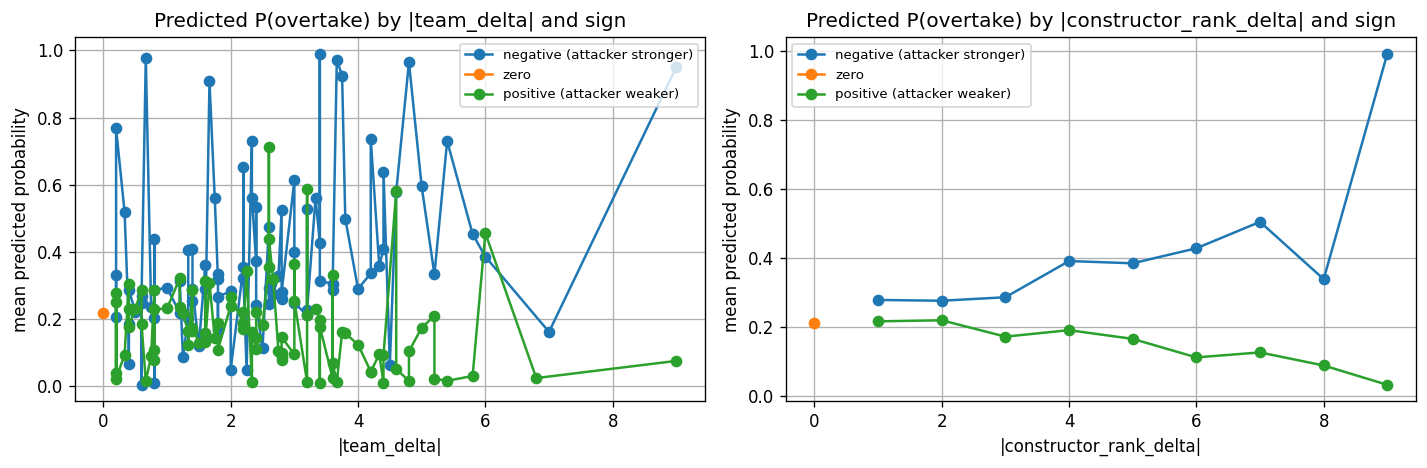

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for sign_val, label in [(-1, "negative (attacker stronger)"), (0, "zero"), (1, "positive (attacker weaker)")]:
    sub = team_tbl[team_tbl["team_sign"] == sign_val]
    if not sub.empty:
        ax[0].plot(sub["abs_team_delta"], sub["mean_pred"], marker="o", label=label)
ax[0].set_title("Predicted P(overtake) by |team_delta| and sign")
ax[0].set_xlabel("|team_delta|")
ax[0].set_ylabel("mean predicted probability")
ax[0].legend(fontsize=8)

for sign_val, label in [(-1, "negative (attacker stronger)"), (0, "zero"), (1, "positive (attacker weaker)")]:
    sub = cons_tbl[cons_tbl["constructor_sign"] == sign_val]
    if not sub.empty:
        ax[1].plot(sub["abs_constructor_rank_delta"], sub["mean_pred"], marker="o", label=label)
ax[1].set_title("Predicted P(overtake) by |constructor_rank_delta| and sign")
ax[1].set_xlabel("|constructor_rank_delta|")
ax[1].set_ylabel("mean predicted probability")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
# Simple explanatory regressions on model output:
# pred_proba ~ signed_delta + abs_delta

def fit_signed_abs(df, signed_col, abs_col):
    X = df[[signed_col, abs_col]].copy()
    y = df["pred_proba"].values
    lr = LinearRegression()
    lr.fit(X, y)
    return {
        "feature_signed": signed_col,
        "coef_signed": lr.coef_[0],
        "feature_abs": abs_col,
        "coef_abs": lr.coef_[1],
        "intercept": lr.intercept_,
        "r2": lr.score(X, y),
    }

res_team = fit_signed_abs(diag, "team_delta", "abs_team_delta")
res_cons = fit_signed_abs(diag, "constructor_rank_delta", "abs_constructor_rank_delta")

summary = pd.DataFrame([res_team, res_cons])
print(summary.round(6).to_string(index=False))

print("\nInterpretation guide:")
print("- Larger |coef_abs| than |coef_signed| suggests magnitude dominates direction.")
print("- A strong negative signed coefficient suggests attacker-stronger direction increases probability.")

        feature_signed  coef_signed                feature_abs  coef_abs  intercept       r2
            team_delta    -0.024487             abs_team_delta  0.010176   0.232146 0.035121
constructor_rank_delta    -0.022100 abs_constructor_rank_delta  0.008519   0.227163 0.067082

Interpretation guide:
- Larger |coef_abs| than |coef_signed| suggests magnitude dominates direction.
- A strong negative signed coefficient suggests attacker-stronger direction increases probability.


In [8]:
# Optional: inspect specific rank matchup examples in the real data

def sample_matchups(df, ac, dc, n=10):
    sub = df[(df["attacker_constructor_rank"] == ac) & (df["defender_constructor_rank"] == dc)]
    keep = [
        "attacker", "defender", "race_name", "lap_number",
        "attacker_constructor_rank", "defender_constructor_rank", "constructor_rank_delta",
        "attacker_team_pace_rank", "defender_team_pace_rank", "team_delta",
        "pred_proba", "actual",
    ]
    if sub.empty:
        return pd.DataFrame(columns=keep)
    return sub[keep].sample(min(n, len(sub)), random_state=42).sort_values("pred_proba", ascending=False)

print("Sample: attacker rank 1 vs defender rank 10")
print(sample_matchups(analysis, 1, 10, n=8).to_string(index=False))

print("\nSample: attacker rank 1 vs defender rank 2")
print(sample_matchups(analysis, 1, 2, n=8).to_string(index=False))

Sample: attacker rank 1 vs defender rank 10
attacker defender                 race_name  lap_number  attacker_constructor_rank  defender_constructor_rank  constructor_rank_delta  attacker_team_pace_rank  defender_team_pace_rank  team_delta  pred_proba  actual
     PIA      HUL Emilia Romagna Grand Prix          21                          1                         10                      -9                      4.4                      7.2        -2.8    0.993177       1

Sample: attacker rank 1 vs defender rank 2
attacker defender                 race_name  lap_number  attacker_constructor_rank  defender_constructor_rank  constructor_rank_delta  attacker_team_pace_rank  defender_team_pace_rank  team_delta  pred_proba  actual
     PIA      ANT      Las Vegas Grand Prix          33                          1                          2                      -1                     3.40                 3.400000    0.000000    0.823543       0
     PIA      RUS    Mexico City Grand Prix     